# TFG - Desarrollo y Evaluación de Modelos de Aprendizaje Automático
**Autor:** Diego de Santos del Río — N.P. 138996  
**Universidad:** Alfonso X El Sabio (UAX)  
**Dataset:** Spanish Houses — mercado inmobiliario español (100.000 viviendas)

---
## Pipeline completo: EDA → Preprocesamiento → Modelos → SHAP

In [1]:
import shap
from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


print("Librerías importadas correctamente")

c:\Users\Diego\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente


## 1. Carga y exploración inicial del dataset

In [ ]:
df = pd.read_csv('dataset/spanish_houses.csv')
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df[['price', 'm2_real', 'room_num', 'bath_num',
    'house_type', 'loc_zone', 'condition']].head()

Dataset cargado: 100,000 filas × 41 columnas


,price,m2_real,room_num,bath_num,house_type,loc_zone,condition
0,310000,1000,4,2,Casa o chalet independiente,"Zuya, Álava",segunda mano/buen estado
1,139000,86,3,2,Ático,"Zuya, Álava",segunda mano/buen estado
2,480000,3000,4,3,Casa de pueblo,"Zuya, Álava",segunda mano/buen estado
3,150000,86,4,1,Casa de pueblo,"Zuya, Álava",segunda mano/buen estado
4,90000,76,2,1,Piso,"Zuya, Álava",segunda mano/buen estado


In [3]:
# Conversión de columnas numéricas cargadas como string
df['price'] = pd.to_numeric(df['price'],   errors='coerce')
df['m2_real'] = pd.to_numeric(df['m2_real'], errors='coerce')
df['m2_useful'] = pd.to_numeric(df['m2_useful'], errors='coerce')
df['renta_media_prov'] = pd.to_numeric(df['renta_media_prov'], errors='coerce')
df['population_prov'] = pd.to_numeric(df['population_prov'],  errors='coerce')
df['companies_prov_vs_national_%'] = pd.to_numeric(
    df['companies_prov_vs_national_%'], errors='coerce')
print('Columnas numéricas convertidas correctamente')

# Estadísticas descriptivas de la variable objetivo
print("\nEstadísticas descriptivas de 'price':")
print(df['price'].describe().apply(lambda x: f'{x:,.2f}'))

print("\nPorcentaje de valores nulos por columna (top 15):")
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].head(15).round(2).to_string())

Columnas numéricas convertidas correctamente

Estadísticas descriptivas de 'price':
count        99,817.00
mean        379,390.28
std         615,498.55
min               1.00
25%         120,000.00
50%         212,000.00
75%         395,000.00
max      23,000,000.00
Name: price, dtype: str

Porcentaje de valores nulos por columna (top 15):
ground_size         99.82
unfurnished         99.35
kitchen             97.79
loc_street          85.69
heating             74.29
construct_date      67.94
orientation         60.58
garage              59.19
loc_neigh           56.31
m2_useful           47.34
lift                41.04
renta_media_prov    40.72
energetic_certif    25.31
floor               20.31
condition           13.94


## 2. Análisis Exploratorio de Datos (EDA)

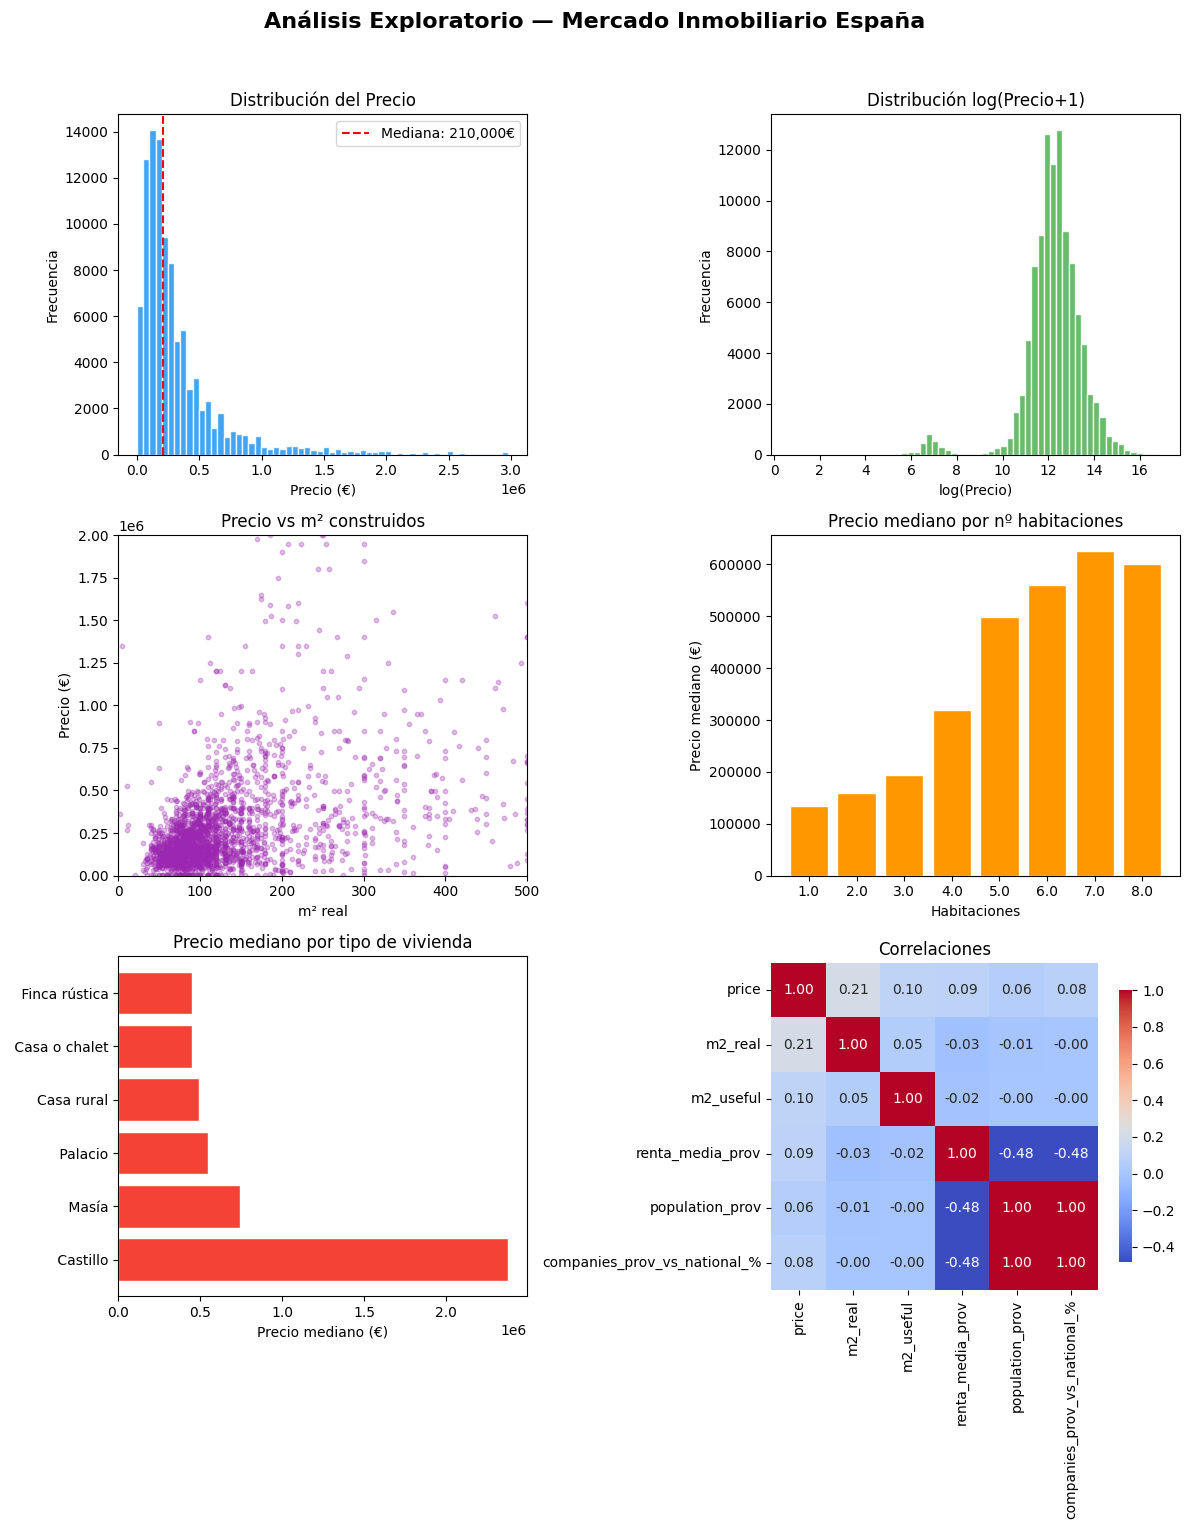

In [ ]:
# Cambiamos a 3 filas y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
fig.suptitle('Análisis Exploratorio — Mercado Inmobiliario España',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Distribución del precio (Fila 0, Col 0) - Zoom al percentil 99
limite_superior = df['price'].quantile(0.99)
data_filtrada = df[df['price'] <= limite_superior]['price'].dropna()

axes[0, 0].hist(data_filtrada, bins=60, color='#2196F3',
                edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribución del Precio')
axes[0, 0].set_xlabel('Precio (€)')
axes[0, 0].set_ylabel('Frecuencia')

# Calculamos la mediana de la muestra filtrada para que la línea sea representativa
mediana_filtrada = data_filtrada.median()
axes[0, 0].axvline(mediana_filtrada, color='red', linestyle='--',
                   label=f"Mediana: {mediana_filtrada:,.0f}€")
axes[0, 0].legend()

# 2. Log del precio (Fila 0, Col 1)
log_price = np.log1p(df['price'].dropna())
axes[0, 1].hist(log_price, bins=60, color='#4CAF50',
                edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Distribución log(Precio+1)')
axes[0, 1].set_xlabel('log(Precio)')
axes[0, 1].set_ylabel('Frecuencia')

# 3. Precio vs m2 (Fila 1, Col 0)
sample = df[['m2_real', 'price']].dropna().sample(min(3000, len(df)))
axes[1, 0].scatter(sample['m2_real'], sample['price'],
                   alpha=0.3, s=10, color='#9C27B0')
axes[1, 0].set_title('Precio vs m² construidos')
axes[1, 0].set_xlabel('m² real')
axes[1, 0].set_ylabel('Precio (€)')
axes[1, 0].set_xlim(0, 500)
axes[1, 0].set_ylim(0, 2e6)

# 4. Precio por habitaciones (Fila 1, Col 1)
room_price = df.copy()
room_price['room_num'] = pd.to_numeric(room_price['room_num'], errors='coerce')
room_med = room_price.groupby('room_num')['price'].median().dropna()
room_med = room_med[(room_med.index >= 1) & (room_med.index <= 8)]
axes[1, 1].bar(room_med.index.astype(str), room_med.values,
               color='#FF9800', edgecolor='white')
axes[1, 1].set_title('Precio mediano por nº habitaciones')
axes[1, 1].set_xlabel('Habitaciones')
axes[1, 1].set_ylabel('Precio mediano (€)')

# 5. Precio por tipo de vivienda (Fila 2, Col 0)
top_types = df.groupby('house_type')['price'].median(
).sort_values(ascending=False).head(6)
axes[2, 0].barh(top_types.index, top_types.values,
                color='#F44336', edgecolor='white')
axes[2, 0].set_title('Precio mediano por tipo de vivienda')
axes[2, 0].set_xlabel('Precio mediano (€)')

# 6. Mapa de calor de correlaciones (Fila 2, Col 1)
num_cols = ['price', 'm2_real', 'm2_useful', 'renta_media_prov',
            'population_prov', 'companies_prov_vs_national_%']
corr_df = df[num_cols].apply(pd.to_numeric, errors='coerce').corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2, 1], square=True, cbar_kws={'shrink': 0.8})
axes[2, 1].set_title('Correlaciones')

plt.tight_layout()
plt.savefig('images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento e Ingeniería de Características

In [5]:
# Selección de features
FEATURES_NUM = ['m2_real', 'm2_useful', 'renta_media_prov', 'population_prov',
                'companies_prov_vs_national_%']
FEATURES_CAT = ['house_type', 'condition', 'loc_zone', 'floor']
FEATURES_BIN = ['air_conditioner', 'balcony', 'lift', 'terrace', 'garage',
                'garden', 'swimming_pool', 'storage_room', 'chimney', 'built_in_wardrobe']
TARGET = 'price'

df['room_num'] = pd.to_numeric(df['room_num'], errors='coerce')
df['bath_num'] = pd.to_numeric(df['bath_num'],  errors='coerce')
FEATURES_NUM += ['room_num', 'bath_num']

df_model = df[FEATURES_NUM + FEATURES_CAT + FEATURES_BIN + [TARGET]].copy()
for col in FEATURES_BIN + FEATURES_NUM:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Eliminación de outliers
p1,  p99 = df_model[TARGET].quantile(0.01), df_model[TARGET].quantile(0.99)
df_model = df_model[(df_model[TARGET] >= p1) & (df_model[TARGET] <= p99)]
df_model = df_model[df_model['m2_real'].fillna(0).between(20, 1000)]
df_model = df_model.dropna(subset=[TARGET, 'm2_real'])
print(
    f" Dataset limpio: {len(df_model):,} filas  |  Precio: {p1:,.0f}€ – {p99:,.0f}€")

# Feature Engineering
df_model['ratio_util_real'] = (
    df_model['m2_useful'] / df_model['m2_real']).clip(0, 1.1)
df_model['amenity_score'] = df_model[FEATURES_BIN].fillna(0).sum(axis=1)
df_model['rooms_per_m2'] = df_model['room_num'] / df_model['m2_real']

FEATURES_NUM_ENG = FEATURES_NUM + \
    ['ratio_util_real', 'amenity_score', 'rooms_per_m2']
print(f" Features ingeniería: ratio_util_real, amenity_score, rooms_per_m2")

 Dataset limpio: 87,731 filas  |  Precio: 850€ – 2,980,000€
 Features ingeniería: ratio_util_real, amenity_score, rooms_per_m2


In [6]:
df[['price', 'm2_real']].corr()

,price,m2_real
price,1.000000,0.207208
m2_real,0.207208,1.000000


## 4. Pipeline scikit-learn y división Train/Test

In [7]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore',
     sparse_output=False, max_categories=30))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, FEATURES_NUM_ENG),
    ('cat', categorical_transformer, FEATURES_CAT),
])

X = df_model[FEATURES_NUM_ENG + FEATURES_CAT]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Shape preprocesado: {X_train_proc.shape}")

Train: 70,184 | Test: 17,547
Shape preprocesado: (70184, 103)


## 5. Entrenamiento y Evaluación de Modelos

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}


def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, do_cv=True):
    cv_mean, cv_std = None, None
    if do_cv:
        cv_scores = cross_val_score(
            model, X_tr, y_tr, cv=kf, scoring='r2', n_jobs=-1)
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    if do_cv:
        print(f"  CV R²  : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  RMSE   : {rmse:>12,.0f} €")
    print(f"  MAE    : {mae:>12,.0f} €")
    print(f"  R²     : {r2:>12.4f}")
    return {'model': model, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
            'y_pred': y_pred, 'cv_r2_mean': cv_mean, 'cv_r2_std': cv_std}


# Regresión Lineal
results['Regresión Lineal'] = evaluate_model('Regresión Lineal',
                                             LinearRegression(), X_train_proc, X_test_proc, y_train, y_test)

# Ridge
results['Ridge'] = evaluate_model('Ridge',
                                  Ridge(alpha=10.0), X_train_proc, X_test_proc, y_train, y_test)


─────────────────────────────────────────────
  Regresión Lineal
─────────────────────────────────────────────
  CV R²  : -1677137949876255.7500 ± 3354275899752512.5000
  RMSE   : 47,740,878,940,978 €
  MAE    : 720,807,080,121 €
  R²     : -22822365945458044.0000

─────────────────────────────────────────────
  Ridge
─────────────────────────────────────────────
  CV R²  : 0.5404 ± 0.0133
  RMSE   :      214,098 €
  MAE    :      125,800 €
  R²     :       0.5410


In [9]:
# Random Forest con RandomizedSearchCV
print("Buscando hiperparámetros para Random Forest...")
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5, 10], 'max_features': ['sqrt', 'log2']},
    n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1, verbose=0)
rf_search.fit(X_train_proc, y_train)
print(f"Mejores params: {rf_search.best_params_}")
results['Random Forest'] = evaluate_model('Random Forest',
                                          rf_search.best_estimator_, X_train_proc, X_test_proc, y_train, y_test, do_cv=False)

Buscando hiperparámetros para Random Forest...
Mejores params: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': None}

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
  RMSE   :      166,399 €
  MAE    :       83,102 €
  R²     :       0.7227


In [10]:
# XGBoost con RandomizedSearchCV
print("Buscando hiperparámetros para XGBoost...")
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions={'n_estimators': [200, 400, 600], 'max_depth': [4, 6, 8],
                         'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.8, 0.9],
                         'colsample_bytree': [0.7, 0.8, 1.0]},
    n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1, verbose=0)
xgb_search.fit(X_train_proc, y_train)
print(f"Mejores params: {xgb_search.best_params_}")
results['XGBoost'] = evaluate_model('XGBoost',
                                    xgb_search.best_estimator_, X_train_proc, X_test_proc, y_train, y_test, do_cv=False)

Buscando hiperparámetros para XGBoost...
Mejores params: {'subsample': 0.9, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
  RMSE   :      163,610 €
  MAE    :       83,442 €
  R²     :       0.7320


In [11]:
# Red Neuronal Densa
print("Entrenando MLP...")
tf.random.set_seed(42)
mlp = keras.Sequential([
    layers.Input(shape=(X_train_proc.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
mlp.compile(optimizer=keras.optimizers.Adam(
    0.001), loss='mse', metrics=['mae'])
history = mlp.fit(X_train_proc, y_train, validation_split=0.15, epochs=150,
                  batch_size=256,
                  callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',
                                                           patience=15, restore_best_weights=True)], verbose=0)
print(f"   Entrenamiento: {len(history.history['loss'])} épocas")
y_pred_mlp = mlp.predict(X_test_proc, verbose=0).flatten()
results['MLP'] = {
    'model': mlp, 'y_pred': y_pred_mlp,
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_mlp)),
    'MAE':  mean_absolute_error(y_test, y_pred_mlp),
    'R2':   r2_score(y_test, y_pred_mlp),
    'cv_r2_mean': None, 'cv_r2_std': None
}
print(
    f"  RMSE: {results['MLP']['RMSE']:,.0f}€  |  MAE: {results['MLP']['MAE']:,.0f}€  |  R²: {results['MLP']['R2']:.4f}")

Entrenando MLP...
   Entrenamiento: 28 épocas
  RMSE: 174,775€  |  MAE: 94,383€  |  R²: 0.6941


## 6. Comparativa de resultados

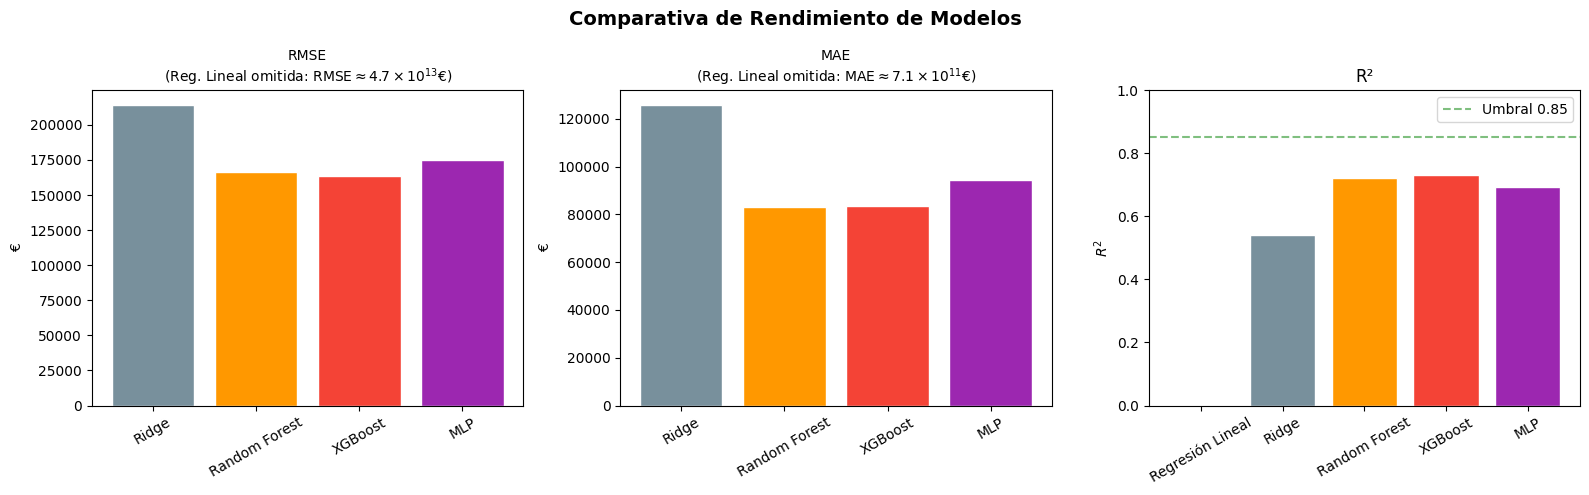

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparativa de Rendimiento de Modelos',
             fontsize=14, fontweight='bold')

names = list(results.keys())
palette = ['#607D8B', '#78909C', '#FF9800', '#F44336', '#9C27B0']

# RMSE (sin regresión lineal)
rmse_plot = [(n, results[n]['RMSE'], c)
             for n, c in zip(names, palette) if n != 'Regresión Lineal']
axes[0].bar([x[0] for x in rmse_plot], [x[1] for x in rmse_plot],
            color=[x[2] for x in rmse_plot], edgecolor='white')
axes[0].set_title('RMSE\n'
                  '(Reg. Lineal omitida: RMSE$\\approx 4.7 \\times 10^{13}$€)', fontsize=10)
axes[0].set_ylabel('€')
axes[0].tick_params(axis='x', rotation=30)

# MAE (sin regresión lineal)
mae_plot = [(n, results[n]['MAE'], c)
            for n, c in zip(names, palette) if n != 'Regresión Lineal']
axes[1].bar([x[0] for x in mae_plot], [x[1] for x in mae_plot],
            color=[x[2] for x in mae_plot], edgecolor='white')
axes[1].set_title('MAE\n'
                  '(Reg. Lineal omitida: MAE$\\approx 7.1 \\times 10^{11}$€)', fontsize=10)
axes[1].set_ylabel('€')
axes[1].tick_params(axis='x', rotation=30)

# R² — todos los modelos
axes[2].bar(names, [results[n]['R2']
            for n in names], color=palette, edgecolor='white')
axes[2].set_title('R²')
axes[2].set_ylabel('$R^2$')
axes[2].set_ylim(0, 1)
axes[2].axhline(0.85, color='green', linestyle='--',
                alpha=0.5, label='Umbral 0.85')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de Predicciones — Mejor Modelo

Mejor modelo: XGBoost  |  R² = 0.7320


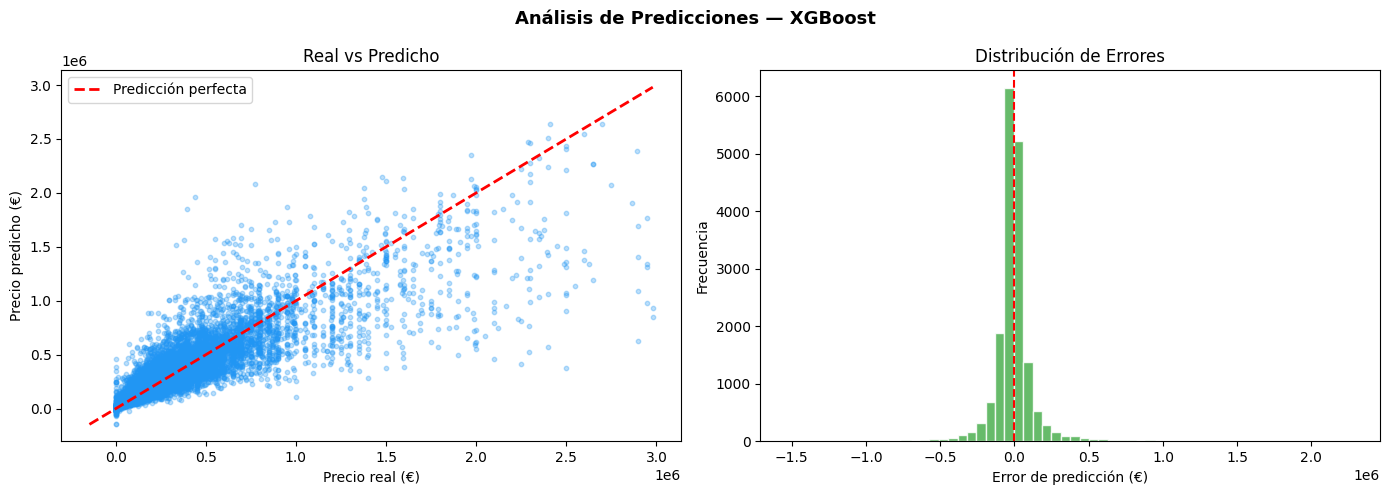

In [ ]:
best_name = max([n for n in results if n != 'MLP'],
                key=lambda n: results[n]['R2'])
print(f"Mejor modelo: {best_name}  |  R² = {results[best_name]['R2']:.4f}")

y_pred_best = results[best_name]['y_pred']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Análisis de Predicciones — {best_name}', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#2196F3')
lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (€)')
axes[0].set_ylabel('Precio predicho (€)')
axes[0].set_title('Real vs Predicho')
axes[0].legend()

errors = y_test.values - y_pred_best
axes[1].hist(errors, bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Error de predicción (€)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores')
plt.tight_layout()
plt.savefig('images/predictions_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interpretabilidad — Análisis SHAP

SHAP calculado sobre 500 muestras


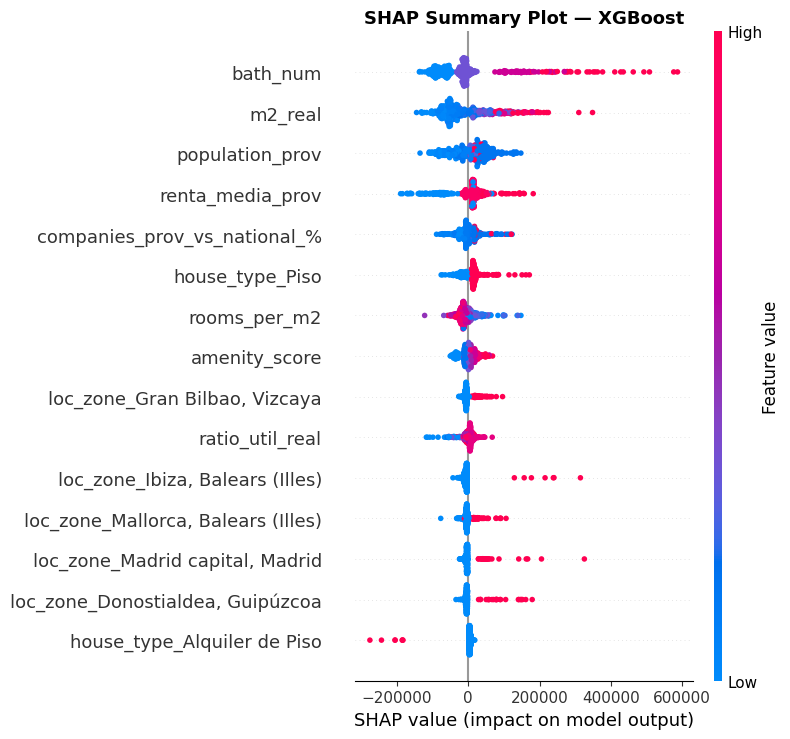

In [ ]:
ohe_feature_names = (preprocessor
                     .named_transformers_['cat']['onehot']
                     .get_feature_names_out(FEATURES_CAT).tolist())
all_feature_names = FEATURES_NUM_ENG + ohe_feature_names

sample_idx = np.random.choice(len(X_test_proc), size=min(
    500, len(X_test_proc)), replace=False)
X_shap = X_test_proc[sample_idx]
explainer = shap.TreeExplainer(results[best_name]['model'])
shap_values = explainer.shap_values(X_shap)
print(f"SHAP calculado sobre {len(sample_idx)} muestras")

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_names,
                  max_display=15, show=False)
plt.title(f'SHAP Summary Plot — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

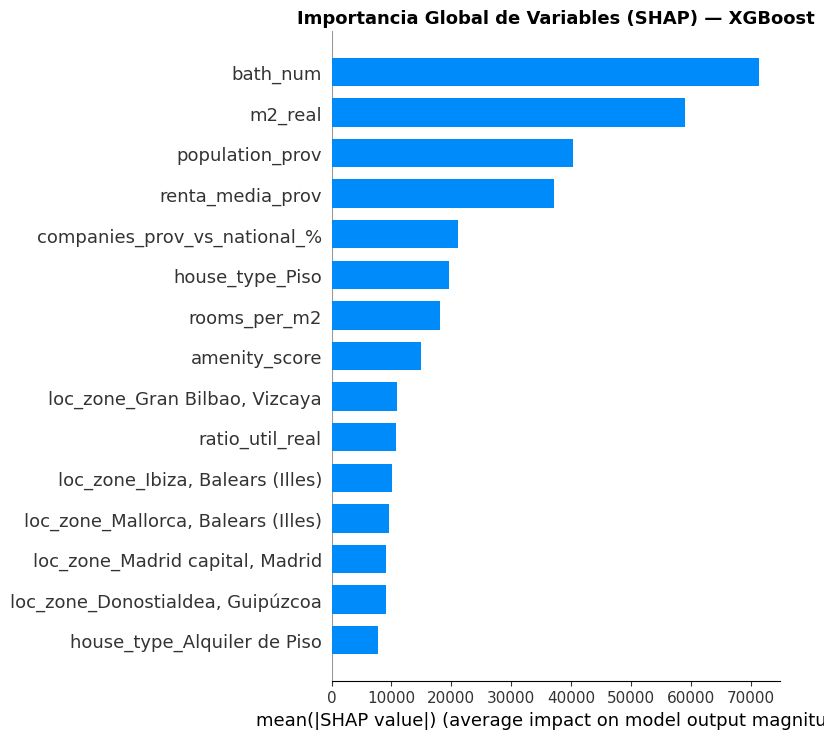


Pipeline completo finalizado.
Mejor modelo: XGBoost  |  R²=0.7320  |  RMSE=163,610€


In [ ]:
# SHAP Bar plot (importancia global)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.title(f'Importancia Global de Variables (SHAP) — {best_name}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPipeline completo finalizado.")
print(
    f"Mejor modelo: {best_name}  |  R²={results[best_name]['R2']:.4f}  |  RMSE={results[best_name]['RMSE']:,.0f}€")

In [16]:
print("=" * 60)
print("TABLA COMPLETA DE MÉTRICAS — TODOS LOS MODELOS")
print("=" * 60)
for name, v in results.items():
    print(f"\n{name}")
    print(f"  RMSE : {v['RMSE']:>15,.2f} €")
    print(f"  MAE  : {v['MAE']:>15,.2f} €")
    print(f"  R²   : {v['R2']:>15.4f}")

TABLA COMPLETA DE MÉTRICAS — TODOS LOS MODELOS

Regresión Lineal
  RMSE : 47,740,878,940,978.43 €
  MAE  : 720,807,080,120.79 €
  R²   : -22822365945458044.0000

Ridge
  RMSE :      214,098.26 €
  MAE  :      125,799.58 €
  R²   :          0.5410

Random Forest
  RMSE :      166,398.86 €
  MAE  :       83,101.73 €
  R²   :          0.7227

XGBoost
  RMSE :      163,610.41 €
  MAE  :       83,441.96 €
  R²   :          0.7320

MLP
  RMSE :      174,775.37 €
  MAE  :       94,382.50 €
  R²   :          0.6941


## 9. Análisis de Robustez y Comportamiento por Segmento


=== ERROR POR SEGMENTO DE PRECIO — XGBoost ===
 segmento    N      MAE_mean   pct_mean   pct_med
    <150k 6447  35573.593922 146.285426 29.233981
150k-300k 5929  58129.942949  27.046673 18.958374
300k-500k 2814 102505.489017  26.316204 20.509081
  500k-1M 1784 175478.346658  25.448678 19.668682
      >1M  573 503764.096531  30.786284 29.033500


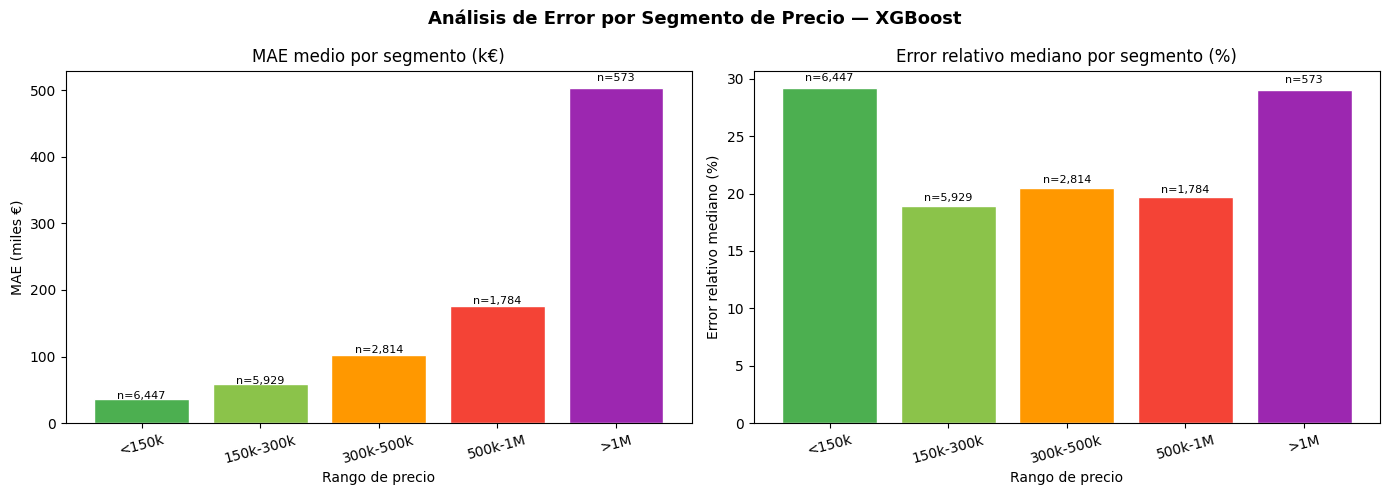

In [ ]:
# Error por segmento de precio
y_test_arr = y_test.values
y_pred_arr = results['XGBoost']['y_pred']
errors_abs = np.abs(y_test_arr - y_pred_arr)
pct_error = errors_abs / y_test_arr * 100  # error relativo

bins = [0, 150_000, 300_000, 500_000, 1_000_000, np.inf]
labels = ['<150k', '150k-300k', '300k-500k', '500k-1M', '>1M']
segmento = pd.cut(y_test_arr, bins=bins, labels=labels)

df_seg = pd.DataFrame({
    'segmento': segmento,
    'MAE':      errors_abs,
    'pct_err':  pct_error,
    'n':        1
})

resumen = df_seg.groupby('segmento', observed=True).agg(
    N=('n',       'count'),
    MAE_mean=('MAE',     'mean'),
    pct_mean=('pct_err', 'mean'),
    pct_med=('pct_err', 'median')
).reset_index()

print("\n=== ERROR POR SEGMENTO DE PRECIO — XGBoost ===")
print(resumen.to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Error por Segmento de Precio — XGBoost',
             fontsize=13, fontweight='bold')

colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336', '#9C27B0']

axes[0].bar(resumen['segmento'], resumen['MAE_mean'] / 1000,
            color=colors, edgecolor='white')
axes[0].set_title('MAE medio por segmento (k€)')
axes[0].set_xlabel('Rango de precio')
axes[0].set_ylabel('MAE (miles €)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(resumen['segmento'], resumen['pct_med'],
            color=colors, edgecolor='white')
axes[1].set_title('Error relativo mediano por segmento (%)')
axes[1].set_xlabel('Rango de precio')
axes[1].set_ylabel('Error relativo mediano (%)')
axes[1].tick_params(axis='x', rotation=15)

# Anotar N en cada barra
for ax, col in zip(axes, ['MAE_mean', 'pct_med']):
    for i, row in resumen.iterrows():
        val = row[col] / 1000 if col == 'MAE_mean' else row[col]
        ax.text(i, val * 1.02, f"n={row['N']:,}", ha='center',
                fontsize=8, color='black')

plt.tight_layout()
plt.savefig('images/error_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()


=== TOP 10 ZONAS CON MAYOR ERROR RELATIVO ===
                      loc_zone    N      MAE_mean   pct_mean
                Almazán, Soria   45  41082.960612 451.342382
       Donostialdea, Guipúzcoa  726 116730.079819 265.323915
Laguardia-Rioja Alavesa, Álava   63  76131.758433 238.040102
         Busturialdea, Vizcaya  117  66988.472556 159.519026
          Área de Soria, Soria  118  38962.565380 156.425243
         Uribe-Butroe, Vizcaya  635  59951.945684 147.031070
            Goierri, Guipúzcoa  162  48450.514612 135.299450
         Duranguesado, Vizcaya  135  47436.636104 120.861918
      Arratia-Nervión, Vizcaya   74  56521.574799 119.665625
          Gran Bilbao, Vizcaya 3129  61788.618014 109.477361

=== TOP 10 ZONAS CON MENOR ERROR RELATIVO ===
                                 loc_zone   N     MAE_mean  pct_mean
                       Salvatierra, Álava  35 44765.850223 17.311653
                       Santiago, A Coruña 230 28913.808781 20.911880
Área Metropolitana Valladoli

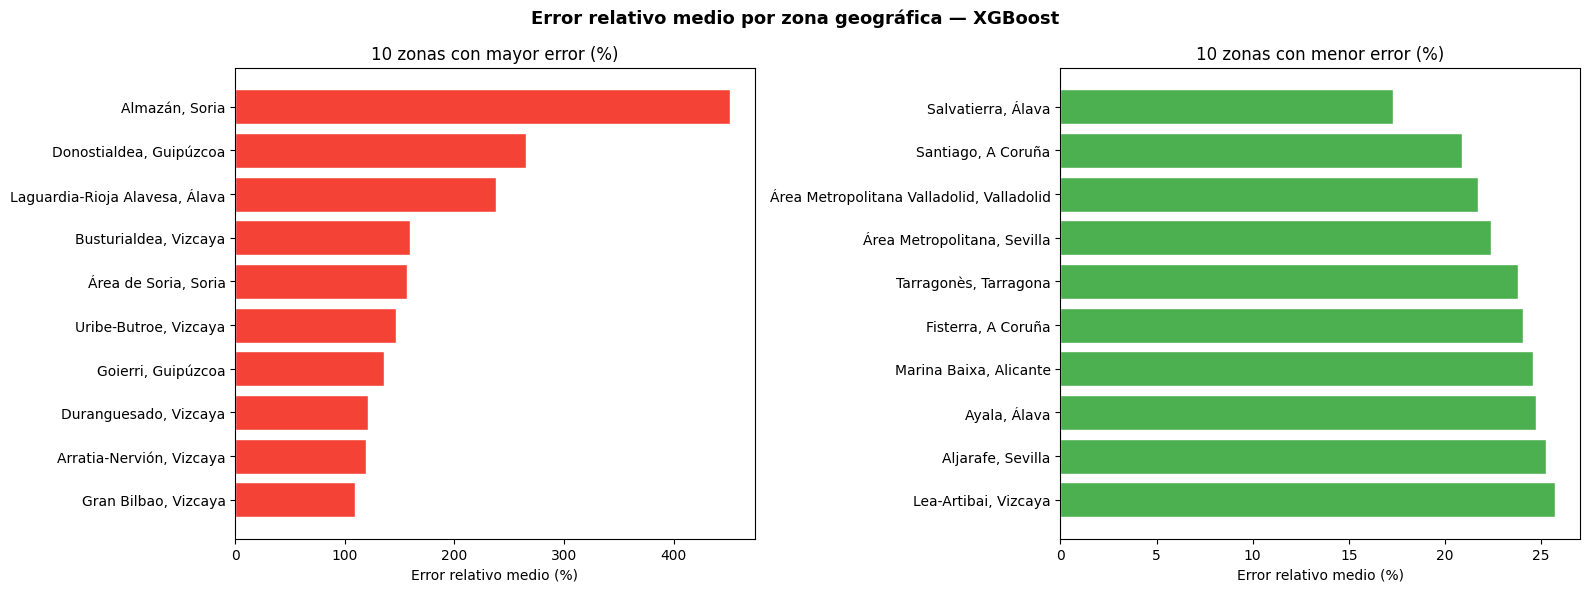

In [ ]:
# Error por zona geográfica

loc_zone_test = df_model.loc[X_test.index, 'loc_zone'].values

df_geo = pd.DataFrame({
    'loc_zone': loc_zone_test,
    'MAE':      errors_abs,
    'pct_err':  pct_error
})

geo_resumen = df_geo.groupby('loc_zone').agg(
    N=('MAE',     'count'),
    MAE_mean=('MAE',     'mean'),
    pct_mean=('pct_err', 'mean')
).reset_index()

# Solo zonas con al menos 30 observaciones
geo_resumen = geo_resumen[geo_resumen['N'] >= 30].copy()

top10_worst = geo_resumen.nlargest(10, 'pct_mean')
top10_best = geo_resumen.nsmallest(10, 'pct_mean')

print("\n=== TOP 10 ZONAS CON MAYOR ERROR RELATIVO ===")
print(top10_worst[['loc_zone', 'N', 'MAE_mean',
      'pct_mean']].to_string(index=False))

print("\n=== TOP 10 ZONAS CON MENOR ERROR RELATIVO ===")
print(top10_best[['loc_zone', 'N', 'MAE_mean',
      'pct_mean']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Error relativo medio por zona geográfica — XGBoost',
             fontsize=13, fontweight='bold')

axes[0].barh(top10_worst['loc_zone'], top10_worst['pct_mean'],
             color='#F44336', edgecolor='white')
axes[0].set_title('10 zonas con mayor error (%)')
axes[0].set_xlabel('Error relativo medio (%)')
axes[0].invert_yaxis()

axes[1].barh(top10_best['loc_zone'], top10_best['pct_mean'],
             color='#4CAF50', edgecolor='white')
axes[1].set_title('10 zonas con menor error (%)')
axes[1].set_xlabel('Error relativo medio (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('images/error_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()


=== DISTRIBUCIÓN DEL ERROR POR SEGMENTO (percentiles) ===
                10%       25%       50%       75%        90%
segmento                                                    
<150k      -76334.0  -42877.0  -17693.0    1857.0    19443.0
150k-300k -118187.0  -57644.0  -10166.0   26532.0    58291.0
300k-500k -181504.0  -77681.0   10154.0   77197.0   132567.0
500k-1M   -221902.0  -61188.0   53423.0  182532.0   296613.0
>1M        -86919.0  106445.0  382904.0  717750.0  1101016.0


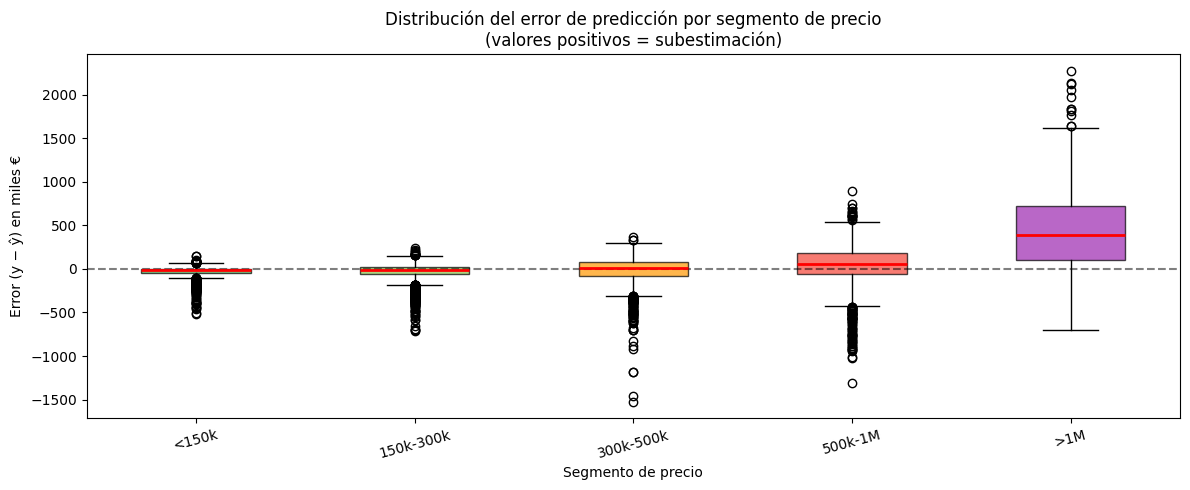


Interpretación rápida:
  <150k       : intervalo P10-P90 = [-76k€, +19k€]
  150k-300k   : intervalo P10-P90 = [-118k€, +58k€]
  300k-500k   : intervalo P10-P90 = [-182k€, +133k€]
  500k-1M     : intervalo P10-P90 = [-222k€, +297k€]
  >1M         : intervalo P10-P90 = [-87k€, +1101k€]


In [ ]:
# Incertidumbre por segmento
df_unc = pd.DataFrame({
    'segmento': segmento,
    'error':    y_test_arr - y_pred_arr   # error con signo
})

unc = df_unc.groupby('segmento', observed=True)['error'].describe(
    percentiles=[0.10, 0.25, 0.5, 0.75, 0.90])

print("\n=== DISTRIBUCIÓN DEL ERROR POR SEGMENTO (percentiles) ===")
print(unc[['10%', '25%', '50%', '75%', '90%']].round(0).to_string())

# Gráfico de caja por segmento
fig, ax = plt.subplots(figsize=(12, 5))
data_plot = [df_unc[df_unc['segmento'] == s]['error'].values / 1000
             for s in labels]
bp = ax.boxplot(data_plot, labels=labels, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Distribución del error de predicción por segmento de precio\n'
             '(valores positivos = subestimación)', fontsize=12)
ax.set_xlabel('Segmento de precio')
ax.set_ylabel('Error (y − ŷ) en miles €')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('images/uncertainty segment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretación rápida:")
for s in labels:
    sub = df_unc[df_unc['segmento'] == s]['error'] / 1000
    p10, p90 = sub.quantile(0.10), sub.quantile(0.90)
    print(f"  {s:12s}: intervalo P10-P90 = [{p10:+.0f}k€, {p90:+.0f}k€]")